# Banco Mundial - Indicadores de Desenvolvimento Mundial

Comparação internacional entre 8 economias: Brasil, Austrália, Canadá, Chile, China, Rússia, EUA e África do Sul.

**Fonte:** Banco Mundial - WDI (últimos 20 anos)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

COUNTRY_LABELS = {
    'AUS': 'Austrália', 'BRA': 'Brasil', 'CAN': 'Canadá', 'CHL': 'Chile',
    'CHN': 'China', 'RUS': 'Rússia', 'USA': 'Estados Unidos', 'ZAF': 'África do Sul'
}
COUNTRY_COLORS = {
    'AUS': '#1f77b4', 'BRA': '#2ca02c', 'CAN': '#d62728', 'CHL': '#ff7f0e',
    'CHN': '#9467bd', 'RUS': '#8c564b', 'USA': '#e377c2', 'ZAF': '#17becf'
}

def get_indicator(df, indicator):
    cols = [c for c in df.columns if c.startswith(indicator + '__')]
    sub = df[cols].copy()
    sub.columns = [c.split('__')[1] for c in sub.columns]
    return sub

def plot_indicator(df, indicator, title, ylabel, highlight=None, hline=None):
    data = get_indicator(df, indicator)
    fig, ax = plt.subplots(figsize=(14, 6))
    for country in data.columns:
        lw = 3 if highlight and country in highlight else 1.2
        alpha = 1.0 if highlight and country in highlight else 0.5
        ax.plot(data.index, data[country], label=COUNTRY_LABELS.get(country, country),
                color=COUNTRY_COLORS.get(country, 'gray'), linewidth=lw, alpha=alpha)
    if hline is not None:
        ax.axhline(y=hline, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Ano')
    ax.legend(loc='best', ncol=2)
    ax.annotate('Fonte: Banco Mundial - WDI', xy=(0.01, -0.1), xycoords='axes fraction', fontsize=8, color='gray')
    plt.tight_layout()
    plt.show()

In [2]:
df = pd.read_csv('../data/worldbank/annual.csv', index_col=0)
df = df[df.index >= 2004]
print(f'Dimensão: {df.shape} | {df.index.min()} a {df.index.max()}')

Shape: (22, 88) | 2004 to 2025


## Valor Adicionado da Indústria (% do PIB)

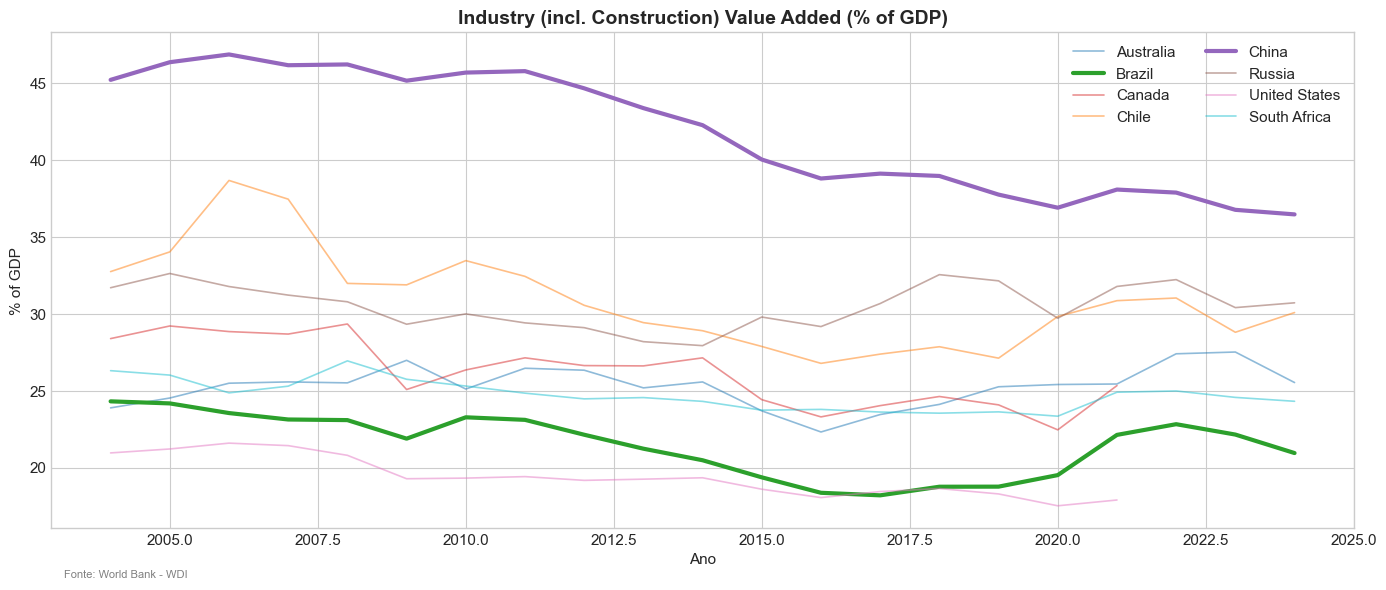

In [3]:
plot_indicator(df, 'industry_gdp_pct',
    'Valor Adicionado da Indústria (incl. Construção) (% do PIB)', '% do PIB',
    highlight=['BRA', 'CHN'])

## Rendas Minerais (% do PIB)

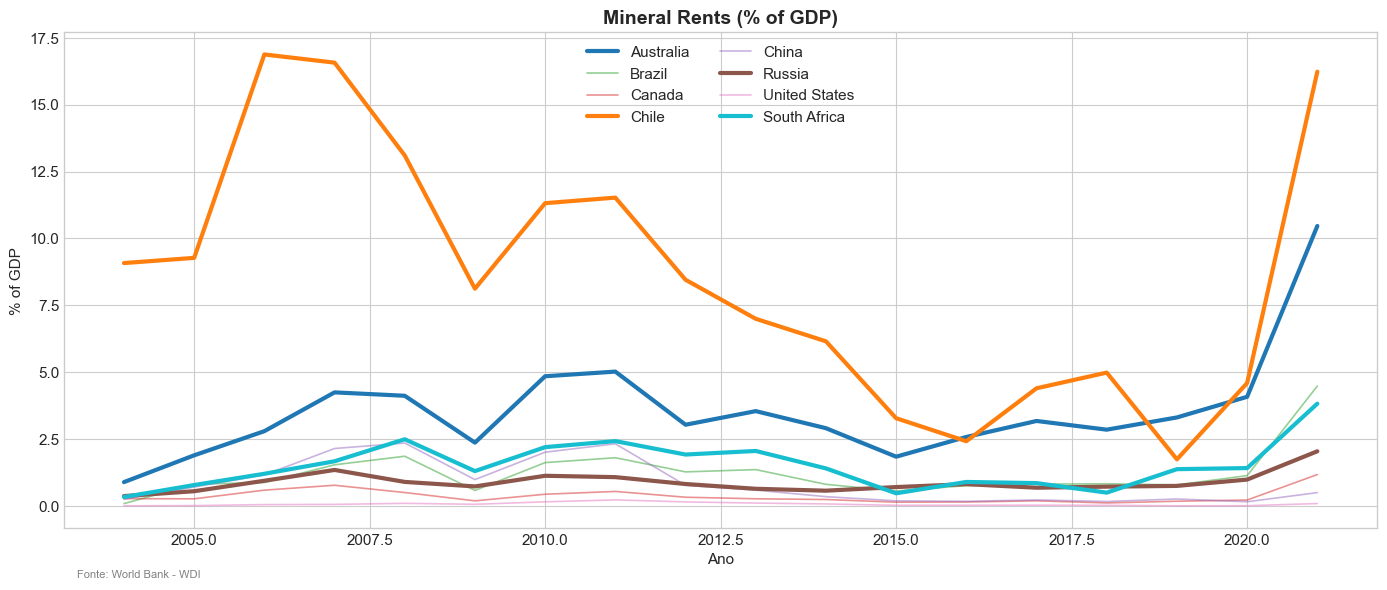

In [4]:
plot_indicator(df, 'mining_rents_pct_gdp',
    'Rendas Minerais (% do PIB)', '% do PIB',
    highlight=['AUS', 'CHL', 'ZAF', 'RUS'])

## Crescimento do PIB (% anual)

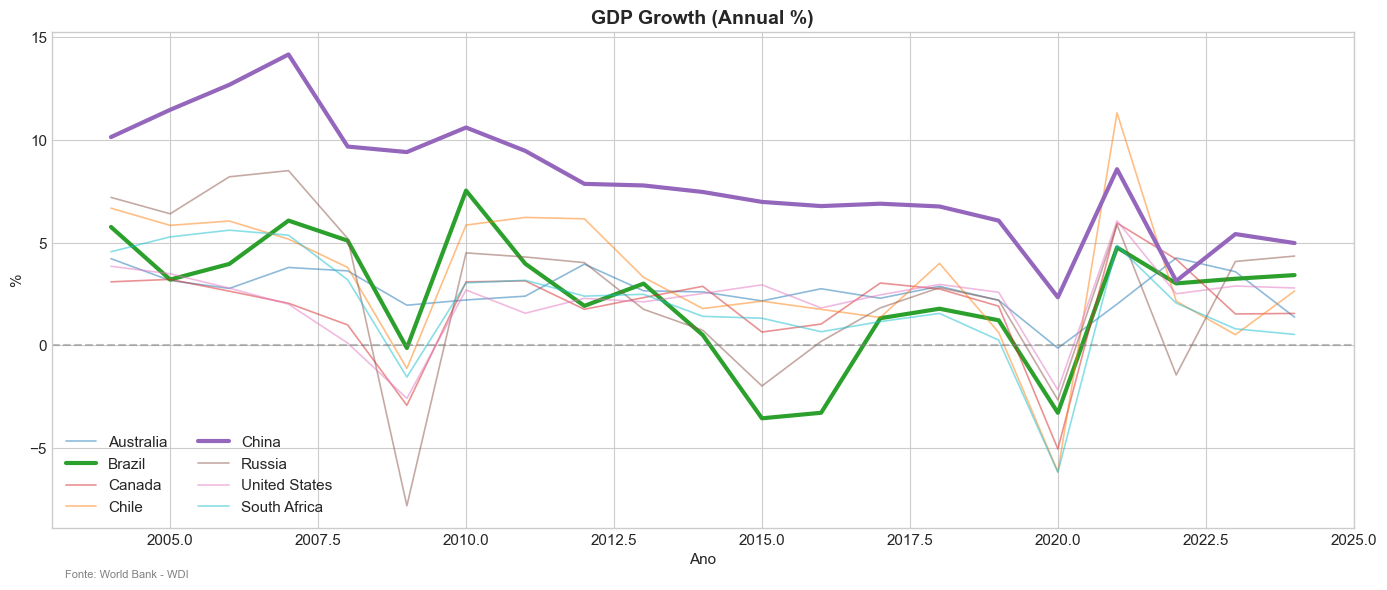

In [5]:
plot_indicator(df, 'gdp_growth',
    'Crescimento do PIB (% anual)', '%',
    highlight=['BRA', 'CHN'], hline=0)

## PIB per Capita (US$ correntes)

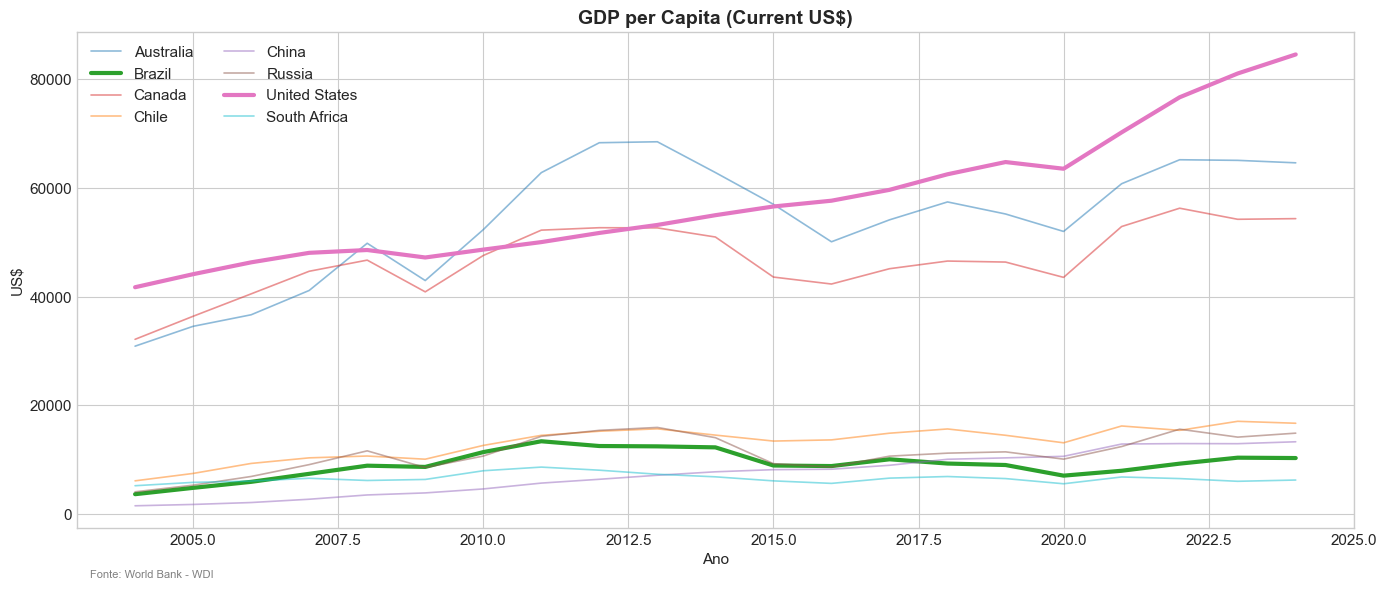

In [6]:
plot_indicator(df, 'gdp_per_capita',
    'PIB per Capita (US$ correntes)', 'US$',
    highlight=['BRA', 'USA'])

## Exportações de Bens e Serviços (% do PIB)

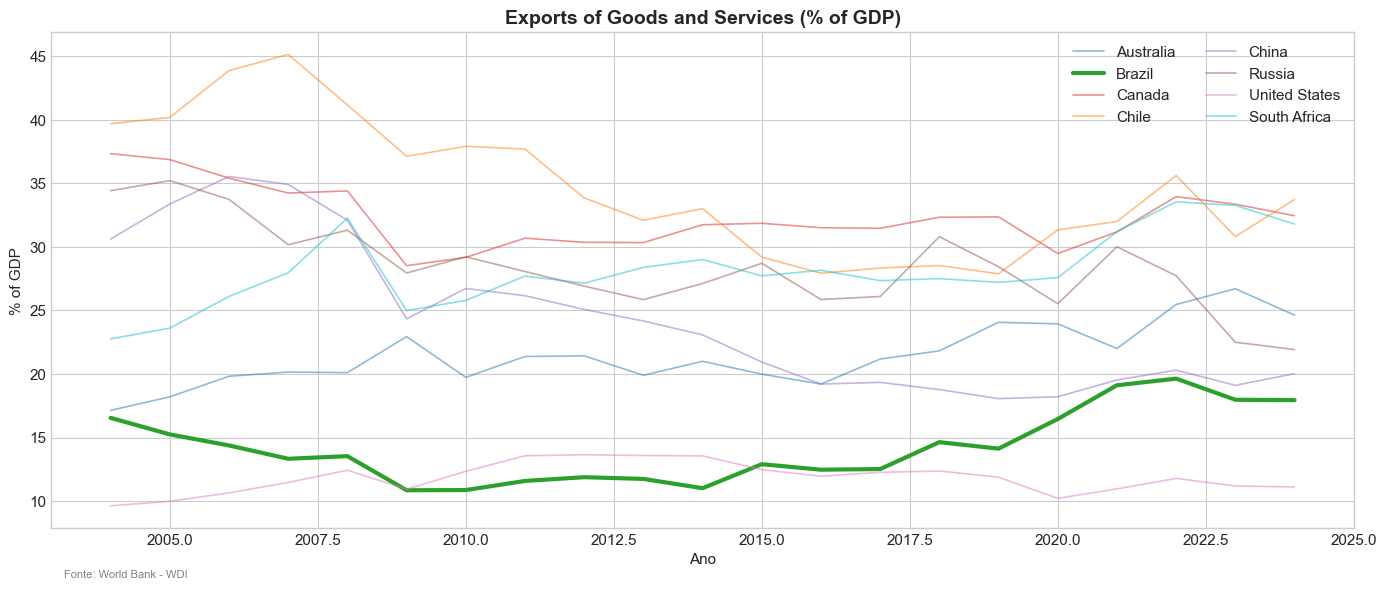

In [7]:
plot_indicator(df, 'exports_goods_services_pct_gdp',
    'Exportações de Bens e Serviços (% do PIB)', '% do PIB',
    highlight=['BRA'])

## Exportações de Minérios e Metais (% das Exportações de Mercadorias)

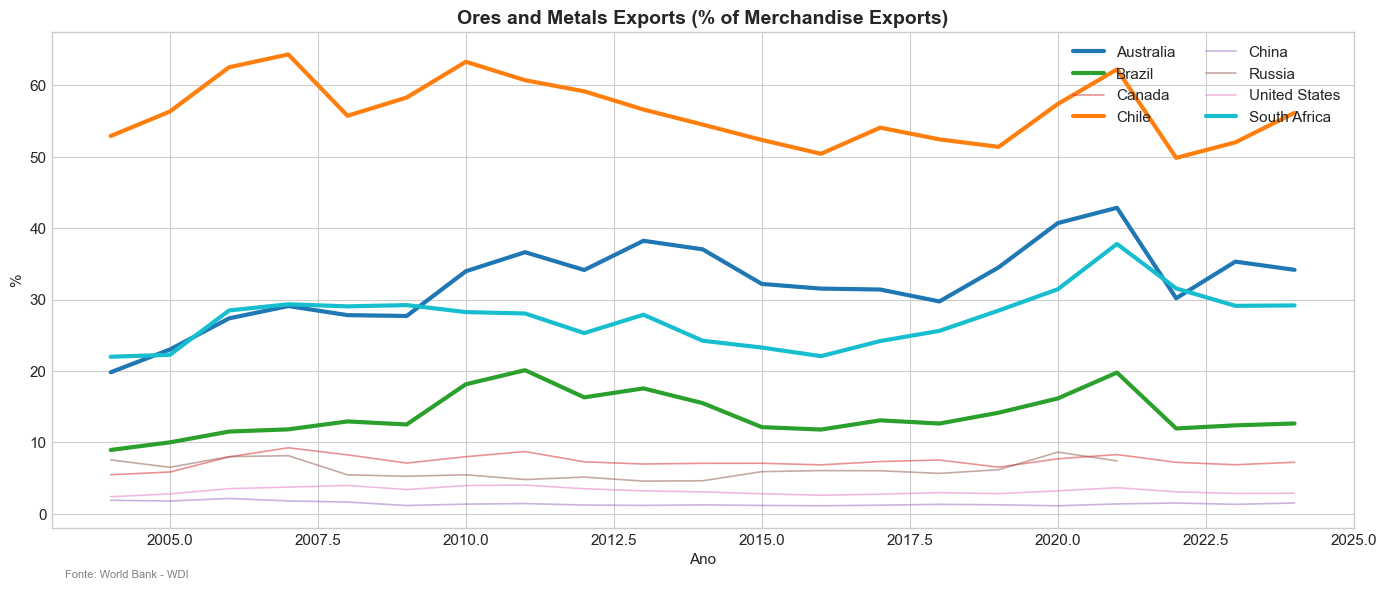

In [8]:
plot_indicator(df, 'ore_metals_exports_pct',
    'Exportações de Minérios e Metais (% das Exp. de Mercadorias)', '%',
    highlight=['BRA', 'AUS', 'CHL', 'ZAF'])

## Exportações de Combustíveis (% das Exportações de Mercadorias)

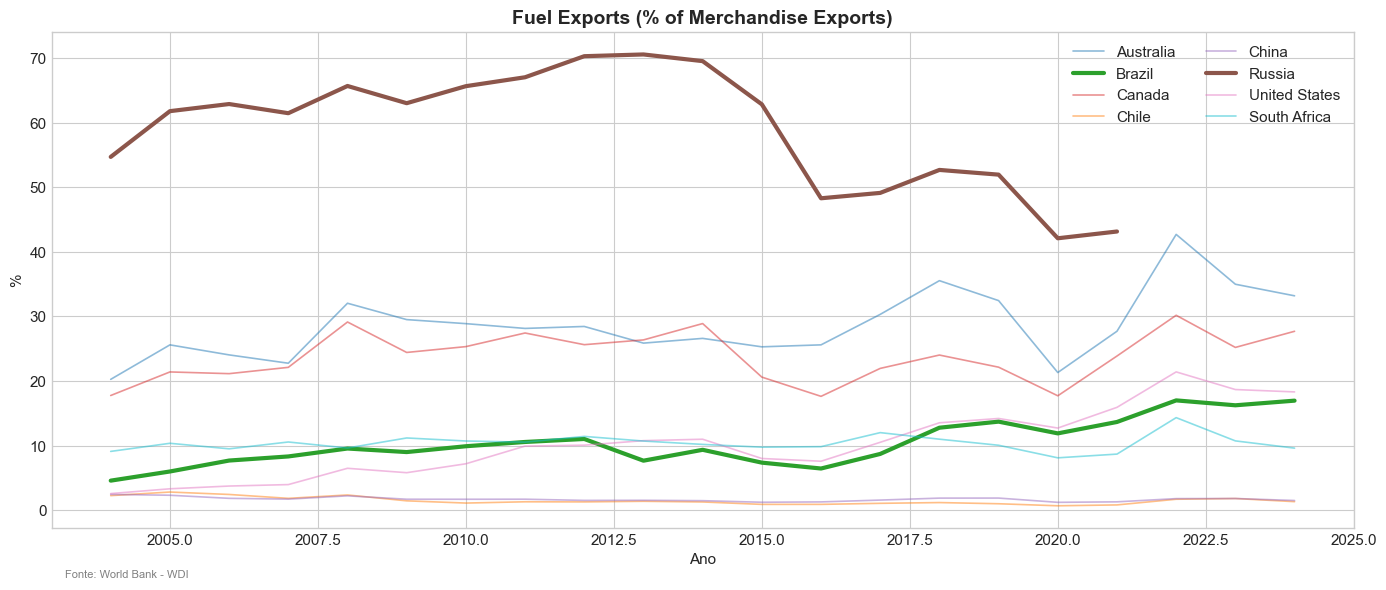

In [9]:
plot_indicator(df, 'fuel_exports_pct',
    'Exportações de Combustíveis (% das Exp. de Mercadorias)', '%',
    highlight=['RUS', 'BRA'])

## Formação Bruta de Capital Fixo (% do PIB)

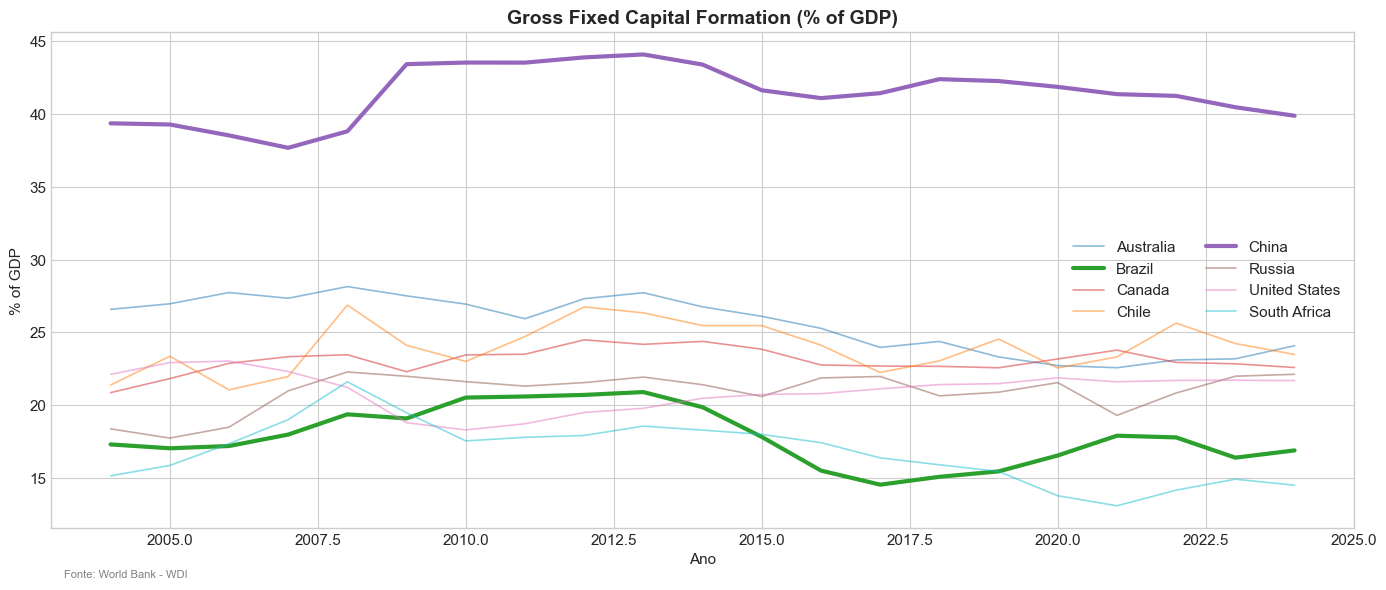

In [10]:
plot_indicator(df, 'gfcf_pct_gdp',
    'Formação Bruta de Capital Fixo (% do PIB)', '% do PIB',
    highlight=['BRA', 'CHN'])

## Inflação - Preços ao Consumidor (% anual)

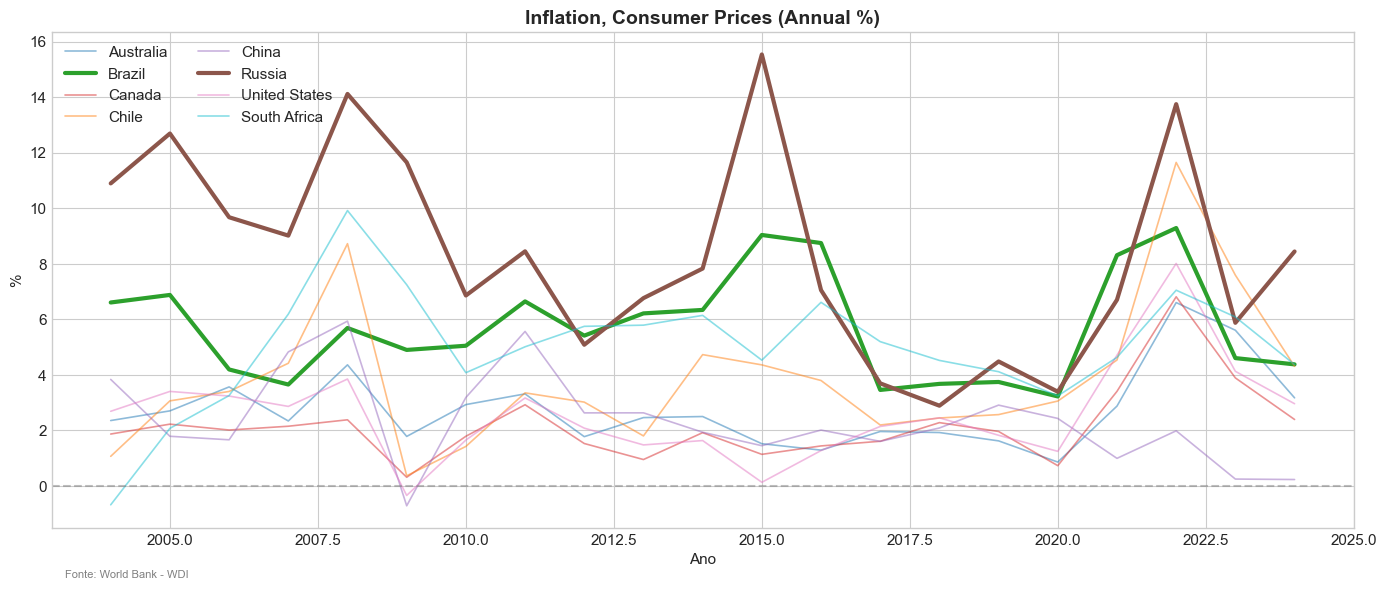

In [11]:
plot_indicator(df, 'inflation_cpi',
    'Inflação - Preços ao Consumidor (% anual)', '%',
    highlight=['BRA', 'RUS'], hline=0)

## Desemprego (% da Força de Trabalho)

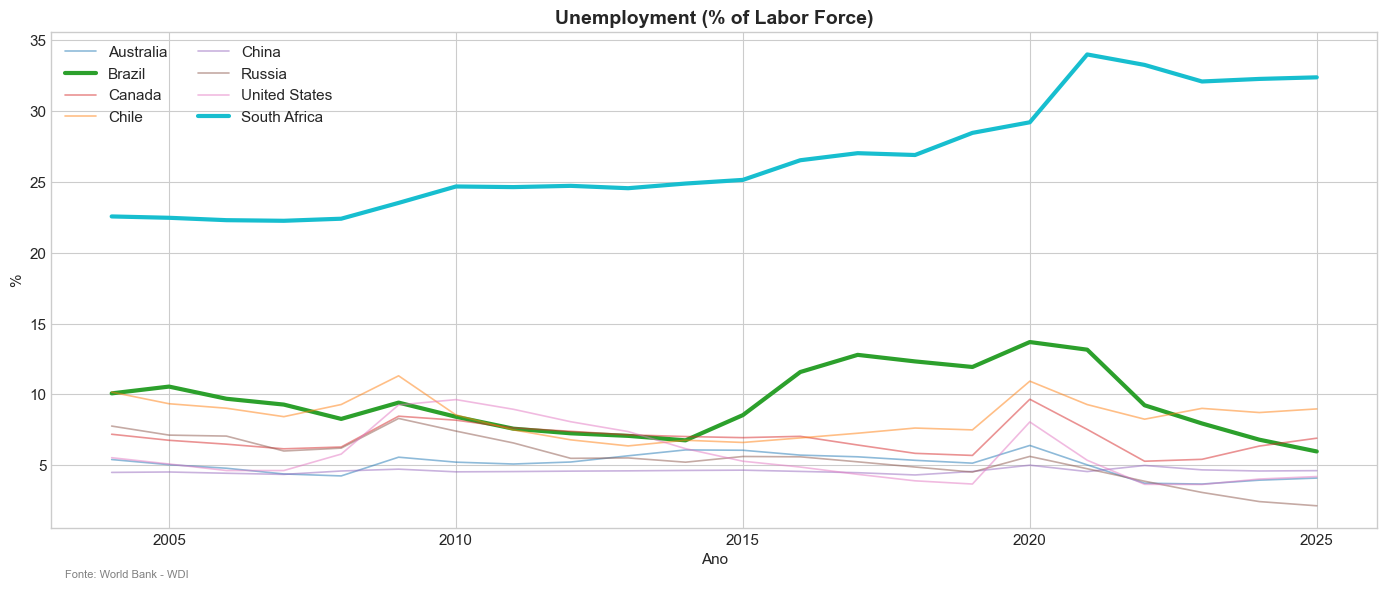

In [12]:
plot_indicator(df, 'unemployment',
    'Desemprego (% da Força de Trabalho)', '%',
    highlight=['BRA', 'ZAF'])

## Rendas Totais de Recursos Naturais (% do PIB)

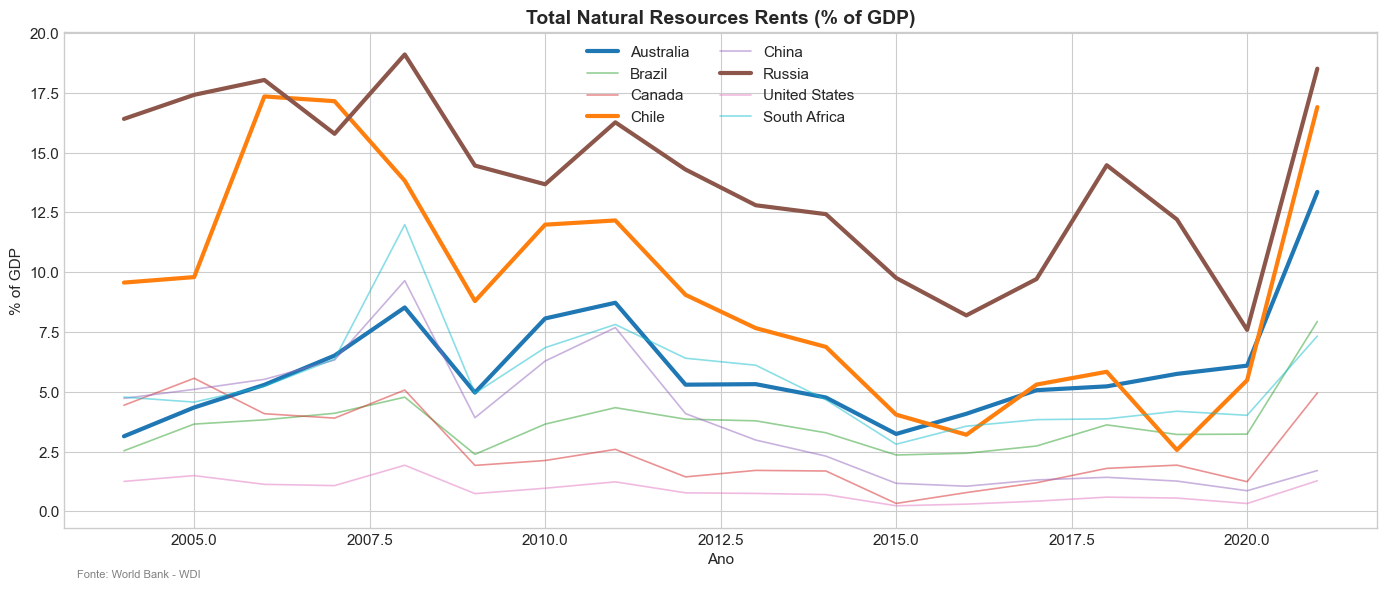

In [13]:
plot_indicator(df, 'total_natural_resources_rents',
    'Rendas Totais de Recursos Naturais (% do PIB)', '% do PIB',
    highlight=['RUS', 'AUS', 'CHL'])

## Painel Resumo - Foco no Brasil

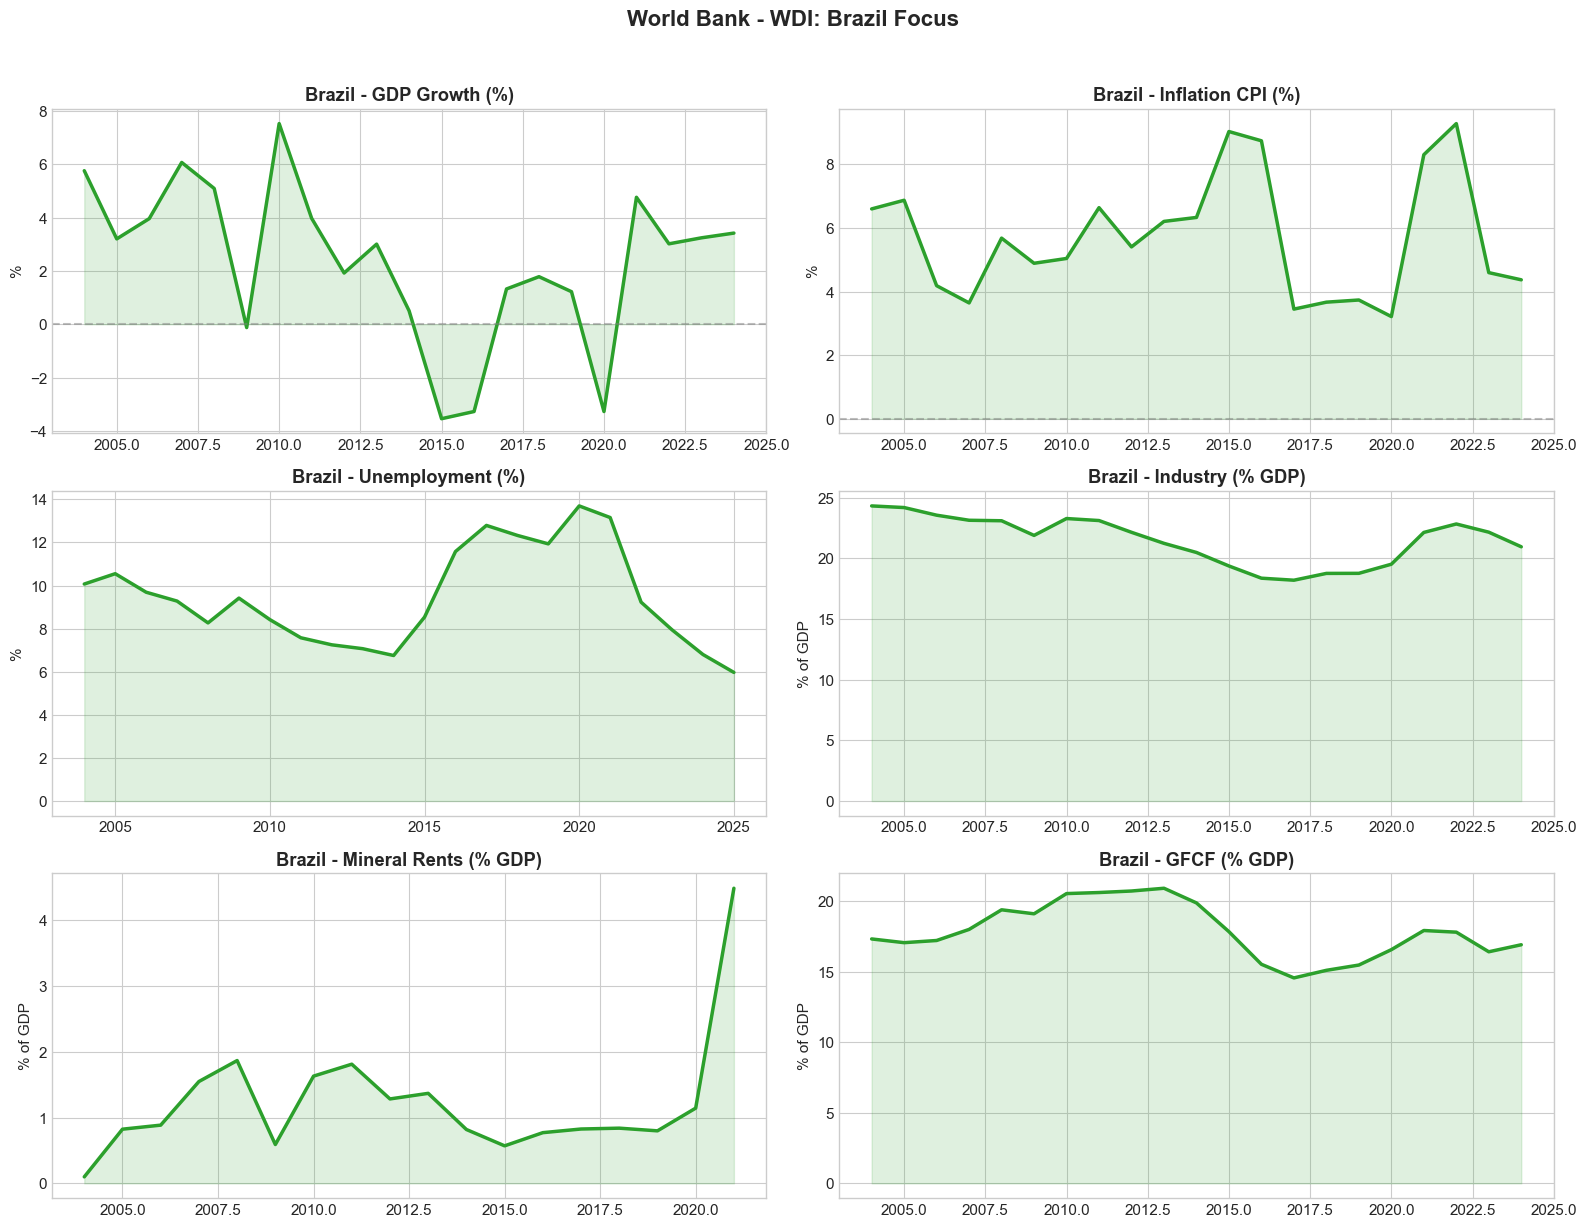

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

panels = [
    ('gdp_growth', 'Crescimento PIB (%)', '%', 0),
    ('inflation_cpi', 'Inflação IPC (%)', '%', 0),
    ('unemployment', 'Desemprego (%)', '%', None),
    ('industry_gdp_pct', 'Indústria (% PIB)', '% do PIB', None),
    ('mining_rents_pct_gdp', 'Rendas Minerais (% PIB)', '% do PIB', None),
    ('gfcf_pct_gdp', 'FBCF (% PIB)', '% do PIB', None),
]

for ax, (ind, title, ylabel, hline) in zip(axes.flat, panels):
    data = get_indicator(df, ind)
    if 'BRA' in data.columns:
        ax.plot(data.index, data['BRA'], color='#2ca02c', linewidth=2.5)
        ax.fill_between(data.index, data['BRA'], alpha=0.15, color='#2ca02c')
    if hline is not None:
        ax.axhline(y=hline, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'Brasil - {title}', fontweight='bold')
    ax.set_ylabel(ylabel)

fig.suptitle('Banco Mundial - WDI: Foco no Brasil', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()